# Chapter 04: Pretraining on unlabeled data
## 4.1 Environment check

Before continuing, run the following code to check if these necessary packages are installed in your environment.

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # for OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.9
numpy version: 2.2.6
tiktoken version: 0.9.0
torch version: 2.13.0
tensorflow version: 2.21.0


We initialize a GPT model using the code from the previous chapters, as shown in `utils/previous_chapters.py`.

In [2]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path

import torch
from utils.previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (original: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(325)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Now that the model's ready, we need additional functions for tokenization and prediction.

In [3]:
import tiktoken
from utils.previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # add a dimension for batch=1
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you mailedizable agoieving Compar river socialistsILL forbid Clouds


## 4.2 Cross-entropy loss and perplexity

Let's simply suppose that the `input` batch size is 2.
- The `targets` are what we desire the model to generate.
- Usually, as mentioned in chapter 01, the `targets` are the `inputs` shifted by 1 position.
- We provide an example below.

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

Instead of observing if the output gives the exact `targets`, we want to measure **the quality of output** compared to `targets`. This is usually described as a *loss function*.
- For a deep learning framework, we expect to find a function $L$
    - The variables of $L$ are the inputs, outputs, labels and parameters
    - If the output is not ideal, the loss function $L$ gives a large value
    - Our goal is to minimize $L$ in some way, such as **training its parameters**
- We've introduced how to use softmax to come up with a probability distribution over all vocabulary tokens. 
    - Generally, we use `argmax` to find out the token with the highest probability to become the next token of the present input token
    - If not trained, the model would give an unexpected output
- So, we need some ways to measure this error.

For an input token with ID $x$, suppose the target token's ID is $y$. We introduce **cross-entropy loss function** of the token as
$$l=-\log P(y)$$

For all input tokens $x_1,\cdots,x_n$ and their target tokens $y_1,\cdots,y_n$, the total loss function is
$$L=\frac{1}{n}\sum_{i=1}^n-\log P(y_i)$$

where $P(y)$ is the output probability of token $y$ after the softmax operation.
- If possible, we wish that $P(y)\rightarrow 1$, so $l\rightarrow 0$
- Otherwise, $P(y)\in(0,1)$ gives a large $l>0$

In [5]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

torch.Size([2, 3, 50257])
Targets batch 1:  effort moves you
Outputs batch 1:  pund Danielle G


Of course, the output above must be quite different from the `targets`. The following code gives the probabilities of those real target tokens.

In [6]:
# there are two text examples above
# probas.shape: (batch_size, num_tokens, vocab_size)
# 1st dim: text_idx=0,1
# 2nd dim: first three output tokens [0, 1, 2] corresponding to the three input tokens
# 3rd dim: real target tokens with index targets[text_idx]

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4030e-06, 3.0733e-05, 1.1955e-05])
Text 2: tensor([1.3522e-05, 3.4898e-05, 1.6544e-05])


Now, we hope to make all these probabilities close to 1. We calculate all these cross-entropy losses and take the average to see the total loss $L$.

In [7]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
ce_loss = torch.mean(-log_probas)
print(ce_loss)

tensor(11.0036)


We can also apply the `cross_entropy` function from `torch.nn.functional`.

In [8]:
logits_flat = logits.flatten(0, 1) # logits.shape: (batch_size, num_tokens, vocab_size)
targets_flat = targets.flatten() # targets.shape: (batch_size, num_tokens)
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])
tensor(11.0036)


Another useful index for measuring the loss of the model is called **perplexity**.
- It's most commonly applied in LLMs compared with cross-entropy loss.
- The perplexity is simply the exponential of the cross-entropy loss.
- It can be understood as *how uncertain the model is about each prediction step*.

In [9]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(60093.0625)


## 4.3 Training and validation set

Before we continue, make sure you've downloaded `the-verdict.txt` in chapter 01 (it is stored in `data/`).

In [10]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
import os

file_path = data_path("the-verdict.txt")
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)


Characters: 20479
Tokens: 5145


Next, we divide the dataset into a **training set** and a **validation set**.
- The training set is used to **train the parameters** to lower the loss function.
- The validation set is used to **improve hyperparameters**, which doesn't take part in the training process. This usually helps prevent overfitting.
- Usually, the train/validation ratio is set to 9:1.

In [11]:
from utils.previous_chapters import create_dataloader_v1

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
# we split the text into [train_data, val_data]
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(325)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True, #shuffle enabled for training
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

# check if the data is loaded correctly
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


For a given batch, we implement a function to calculate the cross-entropy loss function.
- We also implement a function to calculate the loss for any given inputs.

In [12]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    # to use torch.nn.functional.cross_entropy, we need to flat these batches.
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

Now, we can calculate the total loss on the training set and validation set.
- The following code switches to the proper computation device on your computer.

In [13]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")
model.to(device)

# REMEMBER: this is not the training yet
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.973654641045464
Validation loss: 10.970491409301758


## 4.4 Start training

For simplicity, we introduce the basic flow of training a deep learning model.
- Iterate over training epochs. One epoch means a complete pass over the training set.
    1.  Iterate over batches in each training epoch. For each epoch:
        - Reset loss gradients from previous batch iterations. 
        - Calculate loss in current batch.
        - Backward pass to calculate loss gradients. (**Backpropagation**)
        - Update model weights using loss gradients. (SGD, momentum, Adam etc.)
    2. Print training and validation losses.
    3. Generate sample text for visual inspection.

More details such as backpropagation, SGD, and the Adam optimizer are omitted here. You can refer to [my blog](https://www.shiiyu.xyz) for more information about deep learning methods.

The following code can be seen as the structure of
```python
train_model_simple(main loop)   # iteration for epochs
  ├─ calc_loss_batch            # each step: calculate single batch loss (forward)
  ├─ evaluate_model             # each eval_freq step: evaluate the present model
  │     └─ calc_loss_loader     # calculate train/val average losses
  └─ generate_and_print_sample  # each epoch: generate texts with the present model
```

In [14]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 1. initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # 2. main training loop
    for epoch in range(num_epochs):
        model.train()  # set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # calculate loss gradients
            optimizer.step() # update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # optional evaluation step, to visualize the training process
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 3. print a sample text after each epoch
        generate_and_print_sample(model, tokenizer, device, start_context)

    # 4. return all losses recorded
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() # disable dropout
    with torch.no_grad(): # disable gradient training
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Actions speak louder than words. Let's start training!
- You can change some of the hyperparameters (especially epochs) to see different results.
- Reminder: A large number of epochs may cause a long run time.

Ep 1 (Step 000000): Train loss 10.019, Val loss 10.035
Ep 1 (Step 000005): Train loss 8.119, Val loss 8.442
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 6.784, Val loss 7.150
Ep 2 (Step 000015): Train loss 6.184, Val loss 6.682
Every effort moves you, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the
Ep 3 (Step 000020): Train loss 11.177, Val loss 12.835
Ep 3 (Step 000025): Train loss 5.619, Val loss 6.528
Every effort moves you                                                  
Ep 4 (Step 000030): Train loss 5.465, Val loss 6.512
Ep 4 (Step 000035): Train loss 5.022, Val loss 6.457
Every effort moves you, and I had a "--I--I--I. " to the was the I had the"I. "--I. "--I. "--I, the donkey. " to the in the
Ep 5 (Step 000040): Train loss 4.662, Val loss 6.494
Every effort moves you of the Riv, and he was.                                          
Ep 6 (Step 0

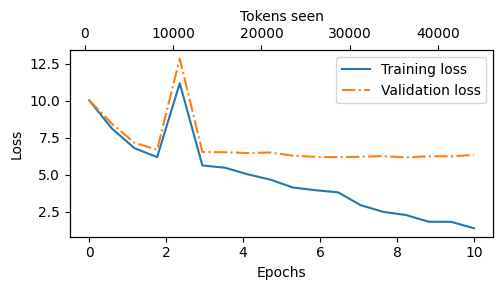

In [15]:
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

start_time = time.time()

model = GPTModel(GPT_CONFIG_124M)
model.to(device)
# using AdamW optimizer with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

# if you want random seeds for training, don't annotate the following row
torch.seed()

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# optional: unannotate the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout() 
    # plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

This is a very small example for training. If you expect a much larger dataset with longer run time and better model performance, you can refer to [Pretraining GPT on the Project Gutenberg Dataset](https://github.com/rasbt/LLMs-from-scratch/tree/main/ch05/03_bonus_pretraining_on_gutenberg) on GitHub.

## 4.5 Decoding strategies

We used a very small model for training, which of course leads to a serious overfitting problem. One strategy is to add randomness during the decoding process to generate abundant texts. There are several options such as
1. Random sampling
2. Temperature scaling
3. Top-K sampling

Let's get started one by one. The first strategy is **random sampling**.
- Previously, we proposed a greedy strategy to give the output with the highest probability using `argmax`.
- To add variety, we sample the next token using `torch.multinomial(probs, num_samples=1)`, which could sample a random token according to the probability distribution in `probs`.
- We provide an example below.

In [16]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = int(torch.argmax(probas).item())

# if we keep using argmax, the output will always be "forward"
print(f"argmax sampling: {inverse_vocab[next_token_id]}\n")

# using temperature scaling method to sample for 1000 times
sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

argmax sampling: forward

63 x closer
2 x every
1 x effort
566 x forward
3 x inches
1 x moves
0 x pizza
359 x toward
5 x you


For the second strategy, **temperature scaling**, it scales all the logits before the softmax.
- It sets a constant $T$ for scaling, which leads to the output probability distribution of
$$probs=\mathrm{softmax}\left(\frac{logits}{T}\right)$$
- Here, $T$ is a controllable hyperparameter:
    - If $T=1$, nothing changes.
    - If $T>1$, the distribution becomes flatter. (More variable)
    - If $T<1$, the distribution becomes sharper. (More stable) 
- We can test $T=0.1,1,5$ for the simple example above.

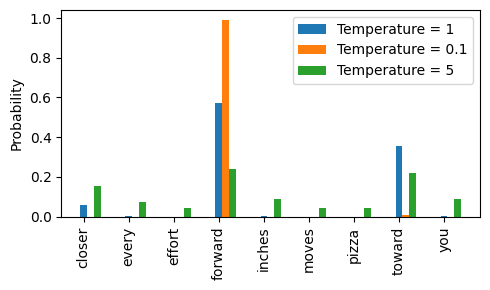

In [17]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# temperature values
temperatures = [1, 0.1, 5]

# calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
# plt.savefig("temperature-plot.pdf")
plt.show()

Here's the third strategy, **Top-K sampling**.
- The basic idea is only keeping the top-k highest probabilities and setting others to `-inf` before the softmax.
- This is usually served with random sampling and temperature scaling.
- The constant $k$ is also a hyperparameter.

In [18]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

# only keeps those top-k tokens
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1], # top_logits[-1] is the k(th) bigger value
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)
print(new_logits)

topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

# you can apply it with random sampling and temperature scaling

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])
tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In all, we can combine these strategies together in the new text generation function.

In [19]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # for-loop is the same as before
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # filter logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id: 
            break

        # same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [20]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know Jack Gisburn rather were up his--so down to the house


## 4.6 Load and save model weights

Once we've got an ideal model after training, it's necessary to save these model parameters (weights) for the future. We can use `model.state_dict()` to see these weights.

In [21]:
print(model.state_dict())

OrderedDict([('tok_emb.weight', tensor([[-1.0640,  1.2952,  0.7296,  ..., -0.5519,  0.2502,  0.0367],
        [-0.9074, -0.7309, -0.1579,  ..., -0.1602,  0.0047, -1.6809],
        [-0.5387, -0.3807,  1.2880,  ..., -1.6287, -0.2297,  1.7864],
        ...,
        [ 1.8736, -0.2359,  1.3577,  ..., -1.5806, -1.5840, -1.1567],
        [ 0.2714,  0.0302, -1.0243,  ...,  1.0459,  0.2444, -0.0258],
        [-1.6892, -0.9752, -0.3305,  ..., -1.4192,  0.0907,  0.6961]],
       device='cuda:0')), ('pos_emb.weight', tensor([[-1.1688,  0.3370, -0.3100,  ..., -1.3826,  0.4902, -0.2304],
        [-1.0432, -1.2696, -1.0398,  ...,  1.1103,  0.2138, -0.2559],
        [-0.2541, -1.7300,  0.0213,  ..., -1.6623,  1.2275,  0.1875],
        ...,
        [ 0.0770,  0.9839, -0.3406,  ...,  1.3113,  1.5232, -1.9302],
        [ 0.9628,  1.1642,  0.8288,  ..., -0.0234,  0.9169, -0.0980],
        [ 0.5443, -1.7902,  1.4026,  ...,  0.5915, -0.7541,  1.2743]],
       device='cuda:0')), ('trf_blocks.0.att.mask', ten

A common way is to save these weights as `.pth` files.
- This should create a new file called `model.pth` inside the `data/` directory.

In [22]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
torch.save(model.state_dict(), data_path("model.pth"))

We can create a new `GPTModel` instance by loading the weights we saved before into it.

In [23]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
model = GPTModel(GPT_CONFIG_124M)
print("Device:", device)

model.load_state_dict(torch.load(data_path("model.pth"), map_location=device, weights_only=True))
model.eval()

Device: cuda


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Usually, we apply adaptive optimizers such as Adam or AdamW instead of the traditional SGD method. It's notable that these adaptive optimizers also have their own weights, so we need to store them together with the model weights.
- Separate model weights and optimizer weights with the following format.

In [24]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    data_path("model_and_optimizer.pth")
)

In [25]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
checkpoint = torch.load(data_path("model_and_optimizer.pth"), weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

## 4.7 Load pretrained weights from OpenAI

Pretrained weights from OpenAI perform better than ours, so we should try to load them locally.
- This process requires `tensorflow`.
- The helper `gpt_download.py` is already provided in `utils/`; import the necessary functions from there.
- After running, you should see `/gpt2/124M` locally.
- If you have any questions, please refer to the Internet yourself.
    - For the network download problem, you should try some *ways* to speed it up. (laugh)

In [26]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
from utils.gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(model_size="124M", models_dir=str(repo_path("gpt2")))

I0000 00:00:1789286545.343698  102864 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789286545.375401  102864 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789286546.308991  102864 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789286546.309181  102864 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU

File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/checkpoint
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/encoder.json
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/hparams.json
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/model.ckpt.index
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/vocab.bpe


After the download, you should find these files in `/gpt2/124M` including
- `checkpoint`: Used for location
- `encoder.json`
- `hparams.json`: Read as `settings`
- `model.ckpt.data-00000-of-00001`: Read as `params`
- `model.ckpt.index`
- `model.ckpt.meta`
- `vocab.bpe`

You can also run the following code to see if the download and load are successful.

In [27]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


Specifically, the structure of `params` is described as follows.
```python
{
    "wte":  np.ndarray (50257, 768),   # token embedding
    "wpe":  np.ndarray (1024, 768),    # position embedding
    "g":    np.ndarray (768,),         # scale in the final LayerNorm
    "b":    np.ndarray (768,),         # shift in the final LayerNorm
    "blocks": [
        {   # 12 attention blocks
            "attn": {
                "c_attn": {"w": (768, 2304), "b": (2304,)},   # Q,K,V (concat)
                "c_proj": {"w": (768, 768),  "b": (768,)}     # attention projection
            },
            "ln_1": {"g": (768,), "b": (768,)},               # LayerNorm before attention layer
            "ln_2": {"g": (768,), "b": (768,)},               # LayerNorm before FFN
            "mlp": {
                "c_fc":   {"w": (768, 3072), "b": (3072,)},   # first layer in FFN
                "c_proj": {"w": (3072, 768), "b": (768,)}     # second layer in FFN
            }
        },
        # ... repeat for 12 times
    ]
}
```

For instance, we can print parameters with key `wte`.

In [28]:
print(params["wte"])
print("Token embedding weight tensor's shape:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor's shape: (50257, 768)


We should assign some configs of `gpt2` to the corresponding weight tensor in the `GPTModel` class we've written.

In [29]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [30]:
# make sure the two input tensors share the same dimension.
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

import numpy as np

# we need to load weights of gpt-2 into our gpt model
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

Finally, using `generate()` in 4.6, we can generate new text with the weights of the original `gpt2` model. You could find that the output looks fine compared to our trained models.

In [31]:
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you. And some effort fails and you don't see some of this light." Even when an old one still feels young and alive
